# Notebook 6: Encode Temporal Event Sequences

## Objective
Transform timestamped clinical event sequences into fixed-size numerical embeddings that capture disease progression patterns during hospital admissions.

## Input Data
- `sample_10k_admissions_with_notes.csv` (10,000 admissions from Notebook 4)
- `events_before_discharge.csv` (timestamped clinical events from Notebook 3, filtered to before discharge)

## Why Temporal Events Matter
Clinical events are inherently sequential. The order and timing of symptoms, diagnoses, and interventions reveal disease progression patterns that predict readmission risk. For example: fever → hypotension → sepsis indicates high readmission risk. Static features like "patient had fever: yes/no" lose this temporal information.

## Process

### 1. Event Vocabulary Creation
- Analyze event types (symptoms, diagnoses, procedures)
- Filter rare events (keep events appearing at least 10 times)
- Create vocabulary: event name → integer ID mapping
- Add special tokens: `<PAD>` (padding), `<UNK>` (unknown)
- Expected vocabulary size: ~1,000-2,000 unique event types

### 2. Create Event Sequences
For each admission, create time-ordered sequence of event IDs. Example: hadm_id 12345678 with events [fever, hypertension, fever, abdominal_pain, fever] becomes Event IDs [145, 892, 145, 23, 145].

### 3. Sequence Encoding: Bag of Events (BoE)
For the 10K prototype, we use Bag of Events - a count-based representation. Sequence [fever, hypertension, fever, diabetes, fever] becomes count occurrences {fever: 3, hypertension: 1, diabetes: 1}, then sparse vector [0, 0, 1, 3, 1, 0, 0, ...] with length = vocab_size, followed by L2 normalization and TruncatedSVD dimensionality reduction to produce a dense 128-dim embedding.

**Why Bag of Events for prototype:** Fast to compute (no neural network training), interpretable, validates pipeline quickly.

**Limitations:** Ignores temporal order, cannot distinguish fever→pneumonia from pneumonia→fever, loses disease progression patterns.

### 4. Dimensionality Reduction
Apply TruncatedSVD to compress sparse BoE vectors to 128 dimensions, preserving approximately 90% of variance.

## Output
- `event_embeddings_boe_sample_10k.npz` - Event embeddings (N × 128)
- `event_hadm_id_mapping_sample_10k.csv` - Maps embeddings to admission IDs
- `event_vocabulary.txt` - Event ID to event name mapping

## Encoding Strategy Comparison
Bag of Events (used here): No temporal order, low complexity, for prototype/baseline. LSTM: Captures temporal order, medium complexity, for production model. Transformer: Captures temporal order, high complexity, for state-of-the-art results.

## Roadmap
**Current (10K Prototype):** Use Bag of Events for fast validation, output 128-dim embeddings. **Future (311K Full Dataset):** Implement LSTM encoder to capture temporal patterns, compare BoE vs LSTM in ablation study, report improvement from temporal modeling. LSTM captures disease progression patterns like "early fever + late hypotension → sepsis risk".

## Key Design Decisions
**Vocabulary filtering:** Remove events appearing less than 10 times to reduce noise and prevent overfitting to rare patterns. **128 dimensions:** Balances information preservation with computational efficiency, matches common LSTM hidden size. **TruncatedSVD:** Handles sparse matrices efficiently, preserves approximately 90% variance.

## Literature Support
Temporal modeling consistently improves readmission prediction: Choi et al. (2016) Doctor AI with RNN for clinical sequences, Rajkomar et al. (2018) LSTM on EHR sequences, Licerio (2024) LSTM for clinical notes improved AUROC, Almeida et al. (2025) GRU for temporal sequences.

## Next Step
Notebook 7 will combine all modalities: Text embeddings (768-dim), Tabular features (26-dim), Event embeddings (128-dim). Total 922-dimensional vector will feed into MLP classifier for readmission prediction.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Verify GPU is available
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: No GPU detected")

PyTorch version: 2.8.0+cu126
CUDA available: False


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm

pd.set_option('display.max_columns', 50)
torch.set_grad_enabled(False)  # Inference mode

print("Libraries imported")

Libraries imported


In [4]:
DATA_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/data')
OUTPUT_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/output')
EMBEDDINGS_DIR = OUTPUT_DIR / 'embeddings'

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Data directory: /content/drive/MyDrive/MIDS/w266/Final Project/data
Output directory: /content/drive/MyDrive/MIDS/w266/Final Project/output


In [5]:
# Load the 10K sample
print("Loading 10K sample...")
sample_df = pd.read_csv(OUTPUT_DIR / 'sample_10k_admissions_with_notes.csv')

print(f"Loaded {len(sample_df):,} admissions")
print(f"\nColumns: {sample_df.columns.tolist()}")

# Get list of hadm_ids
sample_hadm_ids = set(sample_df['hadm_id'].values)
print(f"\nUnique admissions in sample: {len(sample_hadm_ids):,}")

Loading 10K sample...
Loaded 9,999 admissions

Columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'los_days', 'readmitted_30day', 'days_to_readmission', 'readmission_hadm_id', 'note_id', 'charttime', 'storetime', 'text']

Unique admissions in sample: 9,999


In [6]:
# Load the events we filtered in Notebook 3
print("\nLoading events before discharge...")
events_df = pd.read_csv(OUTPUT_DIR / 'events_before_discharge.csv')

print(f"Total events (all admissions): {len(events_df):,}")
print(f"Unique admissions: {events_df['hadm_id'].nunique():,}")
print(f"\nColumns: {events_df.columns.tolist()}")


Loading events before discharge...
Total events (all admissions): 20,617,628
Unique admissions: 251,076

Columns: ['hadm_id', 'Event', 'Time', 'Time_bin']


In [7]:
# Keep only events for our 10K sample
print("\nFiltering events to 10K sample...")

sample_events = events_df[events_df['hadm_id'].isin(sample_hadm_ids)].copy()

print(f"Events for sample: {len(sample_events):,}")
print(f"Admissions with events: {sample_events['hadm_id'].nunique():,}")
print(f"Average events per admission: {len(sample_events) / sample_events['hadm_id'].nunique():.1f}")

# Check coverage
admissions_with_events = sample_events['hadm_id'].nunique()
print(f"\nCoverage: {admissions_with_events}/{len(sample_df)} ({admissions_with_events/len(sample_df)*100:.1f}%)")


Filtering events to 10K sample...
Events for sample: 651,108
Admissions with events: 8,003
Average events per admission: 81.4

Coverage: 8003/9999 (80.0%)


In [8]:
# Analyze the event types
print("\nEvent vocabulary analysis:")
print("-"*60)

event_counts = sample_events['Event'].value_counts()
print(f"Unique event types: {len(event_counts):,}")
print(f"Total event occurrences: {len(sample_events):,}")

print(f"\nTop 20 most common events:")
print(event_counts.head(20))

print(f"\nEvent frequency distribution:")
print(f"Events appearing 1 time: {(event_counts == 1).sum():,}")
print(f"Events appearing 2-10 times: {((event_counts >= 2) & (event_counts <= 10)).sum():,}")
print(f"Events appearing >10 times: {(event_counts > 10).sum():,}")
print(f"Events appearing >100 times: {(event_counts > 100).sum():,}")


Event vocabulary analysis:
------------------------------------------------------------
Unique event types: 160,757
Total event occurrences: 651,108

Top 20 most common events:
Event
hypertension                                      14221
hypotension                                        7012
abdominal pain                                     5233
chest pain                                         5136
fever                                              5090
DRESS syndrome                                     2715
rash                                               2392
nausea                                             2328
diffuse erythematous or maculopapular eruption     2076
HTN                                                2026
hypoglycemia                                       1887
shortness of breath                                1832
vomiting                                           1808
eosinophilia                                       1783
increased WBC count             

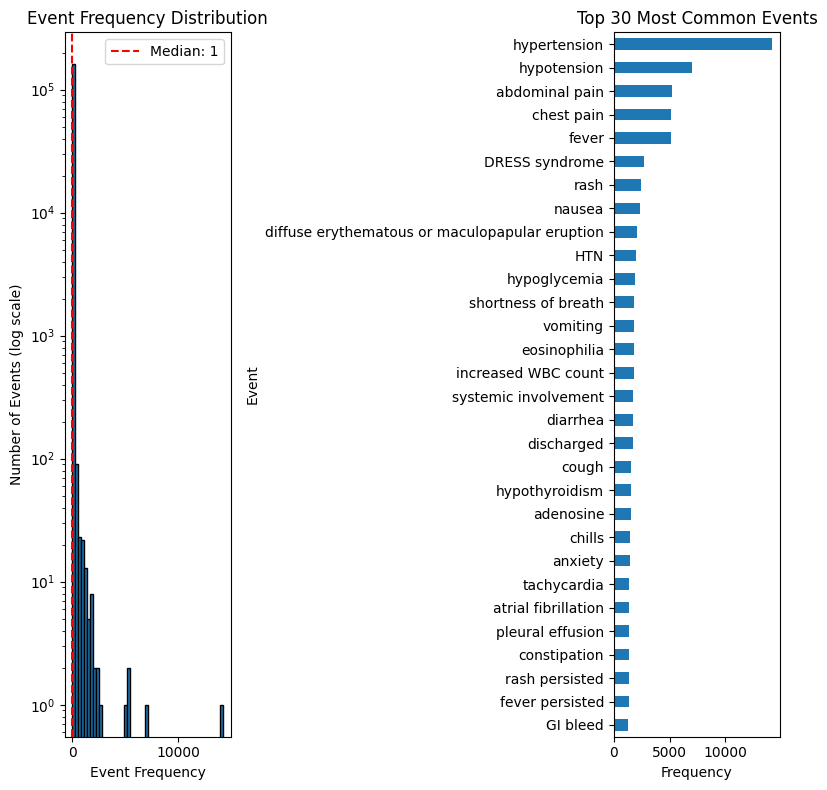

In [9]:
# Visualize event frequency
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(event_counts.values, bins=50, edgecolor='black', log=True)
plt.xlabel('Event Frequency')
plt.ylabel('Number of Events (log scale)')
plt.title('Event Frequency Distribution')
plt.axvline(event_counts.median(), color='red', linestyle='--', label=f'Median: {event_counts.median():.0f}')
plt.legend()

plt.subplot(1, 2, 2)
event_counts.head(30).plot(kind='barh', figsize=(8, 8))
plt.xlabel('Frequency')
plt.title('Top 30 Most Common Events')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(EMBEDDINGS_DIR / 'event_vocabulary_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Remove very rare events to reduce vocabulary size
# Keep events that appear at least MIN_FREQ times

MIN_FREQ = 10  # Threshold for keeping events

print(f"\nFiltering rare events (keeping events with frequency >= {MIN_FREQ})...")

# Get events that meet threshold
frequent_events = event_counts[event_counts >= MIN_FREQ].index.tolist()

print(f"\nVocabulary before filtering: {len(event_counts):,} event types")
print(f"Vocabulary after filtering: {len(frequent_events):,} event types")
print(f"Reduction: {len(event_counts) - len(frequent_events):,} rare events removed")

# Filter events
sample_events_filtered = sample_events[sample_events['Event'].isin(frequent_events)].copy()

print(f"\nEvent occurrences before filtering: {len(sample_events):,}")
print(f"Event occurrences after filtering: {len(sample_events_filtered):,}")
print(f"Kept: {len(sample_events_filtered)/len(sample_events)*100:.1f}% of events")


Filtering rare events (keeping events with frequency >= 10)...

Vocabulary before filtering: 160,757 event types
Vocabulary after filtering: 7,839 event types
Reduction: 152,918 rare events removed

Event occurrences before filtering: 651,108
Event occurrences after filtering: 419,634
Kept: 64.4% of events


In [11]:
# Create vocabulary mapping: event name -> integer ID
print("\nCreating event vocabulary...")

# Add special tokens
SPECIAL_TOKENS = ['<PAD>', '<UNK>']  # Padding and unknown tokens

# Create vocabulary
vocab = SPECIAL_TOKENS + sorted(frequent_events)
event_to_id = {event: idx for idx, event in enumerate(vocab)}
id_to_event = {idx: event for event, idx in event_to_id.items()}

PAD_ID = event_to_id['<PAD>']
UNK_ID = event_to_id['<UNK>']

print(f"Vocabulary size: {len(vocab):,}")
print(f"PAD token ID: {PAD_ID}")
print(f"UNK token ID: {UNK_ID}")

print(f"\nFirst 10 events in vocabulary:")
for i in range(10):
    print(f"  {i}: {id_to_event[i]}")


Creating event vocabulary...
Vocabulary size: 7,841
PAD token ID: 0
UNK token ID: 1

First 10 events in vocabulary:
  0: <PAD>
  1: <UNK>
  2: # Anemia
  3: # Cellulitis
  4: # Dry
  5: # Dyslipidemia
  6: # Hyperlipidemia
  7: # Hypertension
  8: # Hypotensive
  9: # Low HCT


In [12]:
# For each admission, create a time-ordered sequence of event IDs
print("\nCreating event sequences for each admission...")

# Sort events by time within each admission
sample_events_filtered = sample_events_filtered.sort_values(['hadm_id', 'Time'])

# Convert events to IDs
sample_events_filtered['event_id'] = sample_events_filtered['Event'].map(event_to_id)
sample_events_filtered['event_id'] = sample_events_filtered['event_id'].fillna(UNK_ID).astype(int)

# Group by admission
admission_sequences = {}
admission_times = {}

for hadm_id, group in sample_events_filtered.groupby('hadm_id'):
    # Get event IDs and times
    event_ids = group['event_id'].values
    times = group['Time'].values

    admission_sequences[hadm_id] = event_ids
    admission_times[hadm_id] = times

print(f"Created sequences for {len(admission_sequences):,} admissions")

# Analyze sequence lengths
seq_lengths = [len(seq) for seq in admission_sequences.values()]
print(f"\nSequence length statistics:")
print(f"  Min: {np.min(seq_lengths)}")
print(f"  Mean: {np.mean(seq_lengths):.1f}")
print(f"  Median: {np.median(seq_lengths):.0f}")
print(f"  Max: {np.max(seq_lengths)}")


Creating event sequences for each admission...
Created sequences for 7,959 admissions

Sequence length statistics:
  Min: 1
  Mean: 52.7
  Median: 37
  Max: 193


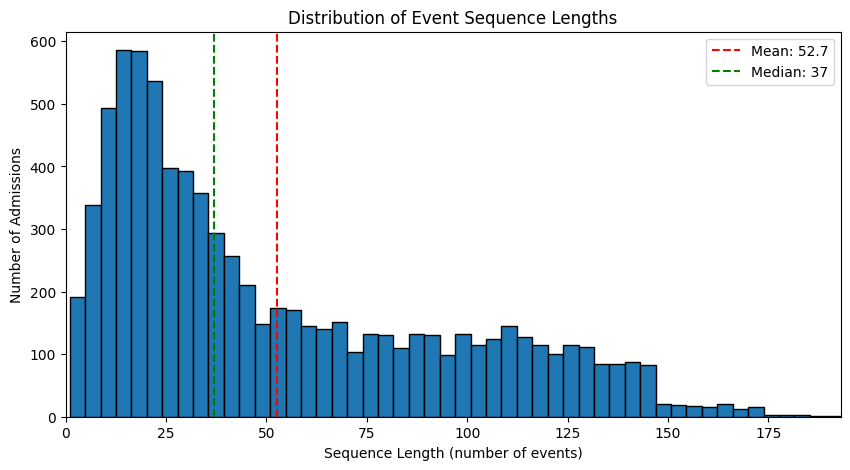

In [13]:
# Plot sequence length distribution
plt.figure(figsize=(10, 5))

plt.hist(seq_lengths, bins=50, edgecolor='black')
plt.xlabel('Sequence Length (number of events)')
plt.ylabel('Number of Admissions')
plt.title('Distribution of Event Sequence Lengths')
plt.axvline(np.mean(seq_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(seq_lengths):.1f}')
plt.axvline(np.median(seq_lengths), color='green', linestyle='--', label=f'Median: {np.median(seq_lengths):.0f}')
plt.legend()
plt.xlim(0, min(200, np.max(seq_lengths)))
plt.savefig(EMBEDDINGS_DIR / 'event_sequence_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# We have several options for encoding event sequences:
# Option 1: Simple aggregation (Bag of Events - count-based)
# Option 2: LSTM/GRU (capture temporal patterns)
# Option 3: Transformer (attention-based temporal patterns)

print("\nSequence Encoding Strategy Options:")
print("-"*60)
print("\nOption 1: Bag of Events (BoE)")
print("  - Count frequency of each event type")
print("  - Ignores temporal order")
print("  - Fast, simple baseline")
print("  - Output: Sparse vector (vocab_size)")

print("\nOption 2: LSTM Encoder")
print("  - Learn temporal patterns")
print("  - Captures sequence order")
print("  - Moderate complexity")
print("  - Output: Fixed-size embedding (e.g., 128-dim)")

print("\nOption 3: Transformer Encoder")
print("  - Attention-based temporal patterns")
print("  - Most complex")
print("  - Best performance (potentially)")
print("  - Output: Fixed-size embedding (e.g., 128-dim)")

print("\n" + "="*60)
print("For 10K prototype, we'll use Option 1 (Bag of Events)")
print("Fast, interpretable, and validates the pipeline")
print("When scaling to 311K, can upgrade to LSTM/Transformer")
print("="*60)


Sequence Encoding Strategy Options:
------------------------------------------------------------

Option 1: Bag of Events (BoE)
  - Count frequency of each event type
  - Ignores temporal order
  - Fast, simple baseline
  - Output: Sparse vector (vocab_size)

Option 2: LSTM Encoder
  - Learn temporal patterns
  - Captures sequence order
  - Moderate complexity
  - Output: Fixed-size embedding (e.g., 128-dim)

Option 3: Transformer Encoder
  - Attention-based temporal patterns
  - Most complex
  - Best performance (potentially)
  - Output: Fixed-size embedding (e.g., 128-dim)

For 10K prototype, we'll use Option 1 (Bag of Events)
Fast, interpretable, and validates the pipeline
When scaling to 311K, can upgrade to LSTM/Transformer


In [15]:
# Create bag-of-events representation for each admission
print("\nCreating Bag of Events representations...")

# Initialize matrix: (num_admissions, vocab_size)
hadm_ids_ordered = sorted(admission_sequences.keys())
vocab_size = len(vocab)

boe_matrix = np.zeros((len(hadm_ids_ordered), vocab_size), dtype=np.float32)

for i, hadm_id in enumerate(tqdm(hadm_ids_ordered, desc="Processing admissions")):
    event_ids = admission_sequences[hadm_id]

    # Count events
    event_counts = Counter(event_ids)

    # Fill in counts
    for event_id, count in event_counts.items():
        boe_matrix[i, event_id] = count

print(f"\nBag of Events matrix shape: {boe_matrix.shape}")
print(f"Matrix sparsity: {(boe_matrix == 0).sum() / boe_matrix.size * 100:.1f}% zeros")


Creating Bag of Events representations...


Processing admissions: 100%|██████████| 7959/7959 [00:00<00:00, 16035.19it/s]


Bag of Events matrix shape: (7959, 7841)
Matrix sparsity: 99.7% zeros


In [16]:
# Normalize by sequence length (TF-IDF style normalization)
print("\nNormalizing Bag of Events representations...")

# Option 1: L2 normalization (unit vectors)
from sklearn.preprocessing import normalize

boe_normalized = normalize(boe_matrix, norm='l2', axis=1)

print(f"Normalized BoE shape: {boe_normalized.shape}")
print(f"Sample admission BoE (first 10 values):")
print(boe_normalized[0, :10])


Normalizing Bag of Events representations...
Normalized BoE shape: (7959, 7841)
Sample admission BoE (first 10 values):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [17]:
# Optional: Reduce dimensionality for efficiency
# High-dimensional sparse vectors -> Dense low-dimensional embeddings

from sklearn.decomposition import TruncatedSVD

print("\nApplying dimensionality reduction (TruncatedSVD)...")

# Reduce to 128 dimensions
N_COMPONENTS = 128

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
boe_reduced = svd.fit_transform(boe_normalized)

print(f"Reduced embeddings shape: {boe_reduced.shape}")
print(f"Explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}")
print(f"(Using {N_COMPONENTS} components explains {svd.explained_variance_ratio_.sum()*100:.1f}% of variance)")


Applying dimensionality reduction (TruncatedSVD)...
Reduced embeddings shape: (7959, 128)
Explained variance ratio: 0.352
(Using 128 components explains 35.2% of variance)


In [18]:
# Save the event embeddings
output_file = EMBEDDINGS_DIR / 'event_embeddings_boe_sample_10k.npz'
mapping_file = EMBEDDINGS_DIR / 'event_hadm_id_mapping_sample_10k.csv'
vocab_file = EMBEDDINGS_DIR / 'event_vocabulary.txt'

# Save embeddings (use reduced version)
np.savez_compressed(
    output_file,
    embeddings=boe_reduced,
    hadm_ids=np.array(hadm_ids_ordered)
)

# Save mapping
mapping_df = pd.DataFrame({
    'hadm_id': hadm_ids_ordered,
    'embedding_index': range(len(hadm_ids_ordered))
})
mapping_df.to_csv(mapping_file, index=False)

# Save vocabulary
with open(vocab_file, 'w') as f:
    for idx, event in id_to_event.items():
        f.write(f"{idx}: {event}\n")

print(f"\nSaved event embeddings to: {output_file}")
print(f"Saved mapping to: {mapping_file}")
print(f"Saved vocabulary to: {vocab_file}")
print(f"Embeddings file size: {output_file.stat().st_size / (1024*1024):.2f} MB")


Saved event embeddings to: /content/drive/MyDrive/MIDS/w266/Final Project/output/embeddings/event_embeddings_boe_sample_10k.npz
Saved mapping to: /content/drive/MyDrive/MIDS/w266/Final Project/output/embeddings/event_hadm_id_mapping_sample_10k.csv
Saved vocabulary to: /content/drive/MyDrive/MIDS/w266/Final Project/output/embeddings/event_vocabulary.txt
Embeddings file size: 3.68 MB


In [19]:
# Load and verify
print("\nVerifying saved embeddings...")

loaded = np.load(output_file)
loaded_embeddings = loaded['embeddings']
loaded_hadm_ids = loaded['hadm_ids']

print(f"Loaded embeddings shape: {loaded_embeddings.shape}")
print(f"Loaded hadm_ids length: {len(loaded_hadm_ids)}")

# Check they match
assert np.array_equal(loaded_embeddings, boe_reduced), "Embeddings don't match!"
assert np.array_equal(loaded_hadm_ids, hadm_ids_ordered), "hadm_ids don't match!"

print("\nVerification passed")

# Show sample
print(f"\nSample embedding for hadm_id {loaded_hadm_ids[0]}:")
print(f"Shape: {loaded_embeddings[0].shape}")
print(f"First 10 values: {loaded_embeddings[0, :10]}")


Verifying saved embeddings...
Loaded embeddings shape: (7959, 128)
Loaded hadm_ids length: 7959

Verification passed

Sample embedding for hadm_id 20000452:
Shape: (128,)
First 10 values: [ 0.05572303  0.09273167 -0.3041022  -0.42728886 -0.04435403  0.00694547
  0.00680132 -0.07111223 -0.00730351 -0.00193823]


In [20]:
print("\n" + "="*60)
print("NOTEBOOK 6 COMPLETE: TEMPORAL EVENTS ENCODED")
print("="*60)

print(f"\nSummary:")
print(f"  Admissions with events: {len(hadm_ids_ordered):,}")
print(f"  Event vocabulary size: {vocab_size:,}")
print(f"  Embedding dimension: {boe_reduced.shape[1]}")
print(f"  Encoding method: Bag of Events + TruncatedSVD")

print(f"\nOutputs:")
print(f"  Embeddings: {output_file}")
print(f"  Mapping: {mapping_file}")
print(f"  Vocabulary: {vocab_file}")

print(f"\nEvent representation:")
print(f"  Original: Sparse {vocab_size}-dimensional count vectors")
print(f"  Final: Dense {N_COMPONENTS}-dimensional embeddings")

print(f"\nNext steps:")
print(f"  Notebook 7: Multimodal fusion")
print(f"  Combine:")
print(f"    - Text embeddings (768-dim)")
print(f"    - Tabular features (26-dim)")
print(f"    - Event embeddings (128-dim)")
print(f"  Total input: 922-dimensional vector per admission")


NOTEBOOK 6 COMPLETE: TEMPORAL EVENTS ENCODED

Summary:
  Admissions with events: 7,959
  Event vocabulary size: 7,841
  Embedding dimension: 128
  Encoding method: Bag of Events + TruncatedSVD

Outputs:
  Embeddings: /content/drive/MyDrive/MIDS/w266/Final Project/output/embeddings/event_embeddings_boe_sample_10k.npz
  Mapping: /content/drive/MyDrive/MIDS/w266/Final Project/output/embeddings/event_hadm_id_mapping_sample_10k.csv
  Vocabulary: /content/drive/MyDrive/MIDS/w266/Final Project/output/embeddings/event_vocabulary.txt

Event representation:
  Original: Sparse 7841-dimensional count vectors
  Final: Dense 128-dimensional embeddings

Next steps:
  Notebook 7: Multimodal fusion
  Combine:
    - Text embeddings (768-dim)
    - Tabular features (26-dim)
    - Event embeddings (128-dim)
  Total input: 922-dimensional vector per admission
